# Step 2 — Data Cleaning & Preprocessing
Walks through every transform in `src/features/cleaning.py` **step by step** — no codebase changes, notebook only.

**Pipeline order**
1. Drop unnamed/index-artifact columns
2. Rename all columns to `snake_case`
3. Drop data-leakage columns
4. Drop rows exceeding missingness threshold
5. Impute residual missing values
6. Parse datetime strings → `datetime64`
7. Extract temporal features (hour, day-of-week, month)
8. Ordinal-encode `Stopovers`
9. Full pipeline composition & save

In [1]:
import sys
import logging
from pathlib import Path

ROOT = Path('../').resolve()
SRC  = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

logging.basicConfig(
    level=logging.INFO,
    format='%(message)s',
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.config import load_config
from features.exploration import load_data
from features.cleaning import (
    COLUMN_RENAME_MAP,
    LEAKAGE_COLUMNS,
    STOPOVER_ORDINAL,
    drop_unnamed_columns,
    rename_columns,
    drop_leakage_columns,
    drop_high_missingness_rows,
    impute_missing,
    parse_datetime_columns,
    extract_temporal_features,
    encode_stopovers,
    build_pipeline,
    save_processed,
    log_report,
    clean,
)

cfg      = load_config(ROOT / 'configs' / 'config.toml')
RAW_PATH = ROOT / cfg['data']['raw_path']

sns.set_theme(style='whitegrid')
print('Setup complete. ROOT:', ROOT)

Setup complete. ROOT: /home/mbarndouka/Documents/amalitechmllab


---
## 1. Load Raw Data
Start from the original CSV — same as Step 1.

In [2]:
raw = load_data(RAW_PATH)
print(f'Raw shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns')
raw.head(3)

Raw shape: 57,000 rows × 17 columns


,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83


In [3]:
# Column names before any transform
print('Columns (raw):')
for c in raw.columns:
    print(f'  {c!r}')

Columns (raw):
  'Airline'
  'Source'
  'Source Name'
  'Destination'
  'Destination Name'
  'Departure Date & Time'
  'Arrival Date & Time'
  'Duration (hrs)'
  'Stopovers'
  'Aircraft Type'
  'Class'
  'Booking Source'
  'Base Fare (BDT)'
  'Tax & Surcharge (BDT)'
  'Total Fare (BDT)'
  'Seasonality'
  'Days Before Departure'


---
## 2. Drop Unnamed Columns
`drop_unnamed_columns()` removes any `Unnamed: N` index-artifact columns that pandas adds when reading a CSV that was saved with `index=True`.  
This dataset has none, so shape stays the same — but the guard matters for robustness.

In [4]:
import re

unnamed_found = [c for c in raw.columns if re.match(r'^unnamed', c, re.IGNORECASE)]
print('Unnamed columns found:', unnamed_found or 'none')

df1 = drop_unnamed_columns(raw)
print(f'Shape after step: {df1.shape}')

Unnamed columns found: none
Shape after step: (57000, 17)


---
## 3. Rename Columns to snake_case
`rename_columns()` maps every original column name to a clean `snake_case` name using `COLUMN_RENAME_MAP`.  
This makes every downstream reference consistent and removes spaces, brackets, and special characters.

In [5]:
# Show the full rename mapping
rename_df = pd.DataFrame(
    list(COLUMN_RENAME_MAP.items()),
    columns=['original', 'renamed']
)
rename_df

,original,renamed
0,Airline,airline
1,Source,source
2,Source Name,source_name
3,Destination,destination
4,Destination Name,destination_name
5,Stopovers,stopovers
6,Aircraft Type,aircraft_type
7,Class,travel_class
8,Booking Source,booking_source
9,Seasonality,seasonality


In [6]:
from functools import partial

df2 = rename_columns(df1, COLUMN_RENAME_MAP)

print('Columns after rename:')
for c in df2.columns:
    print(f'  {c}')

2026-05-14 06:40:36 [INFO] features.cleaning: Renaming 17 column(s) to snake_case


Renaming 17 column(s) to snake_case


Columns after rename:
  airline
  source
  source_name
  destination
  destination_name
  departure_datetime
  arrival_datetime
  duration
  stopovers
  aircraft_type
  travel_class
  booking_source
  base_fare
  tax_surcharge
  fare
  seasonality
  days_left


---
## 4. Drop Data-Leakage Columns
`drop_leakage_columns()` removes `base_fare` and `tax_surcharge`.  
Both are **sub-components of the target** (`fare = base_fare + tax_surcharge`) — keeping them would give the model a trivial arithmetic shortcut instead of learning real flight-price patterns.

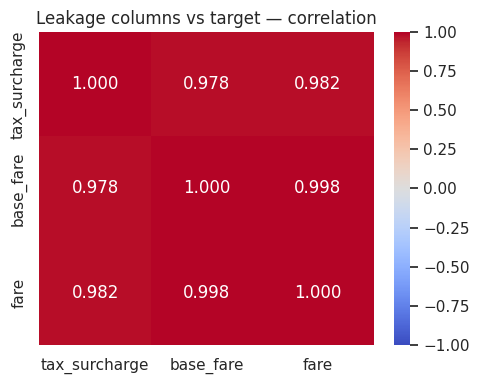

In [7]:
# Visualise the leakage: correlation between leakage columns and target
leakage_renamed = {'base_fare', 'tax_surcharge'}
cols_to_check   = [c for c in leakage_renamed if c in df2.columns] + ['fare']

if len(cols_to_check) > 1:
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        df2[cols_to_check].corr(),
        annot=True, fmt='.3f', cmap='coolwarm',
        vmin=-1, vmax=1, ax=ax
    )
    ax.set_title('Leakage columns vs target — correlation')
    plt.tight_layout()
    plt.show()

In [8]:
leakage_frozenset = frozenset(
    COLUMN_RENAME_MAP.get(c, c) for c in LEAKAGE_COLUMNS
)
df3 = drop_leakage_columns(df2, leakage_frozenset)

print(f'Dropped: {leakage_frozenset}')
print(f'Shape after step: {df3.shape}  (was {df2.shape})')

2026-05-14 06:40:36 [INFO] features.cleaning: Dropping leakage columns: ['base_fare', 'tax_surcharge']


Dropping leakage columns: ['base_fare', 'tax_surcharge']


Dropped: frozenset({'tax_surcharge', 'base_fare'})
Shape after step: (57000, 15)  (was (57000, 17))


---
## 5. Handle Missing Values
Two-stage strategy:
1. **`drop_high_missingness_rows()`** — drop any row where >50% of columns are `NaN` (catastrophically incomplete records)
2. **`impute_missing()`** — fill remaining `NaN`s: median for numerical, `"Unknown"` for categorical

This dataset has zero missing values from Step 1, so both steps are no-ops here — but the pipeline handles them defensively.

In [9]:
# Missing values per column before
missing_before = df3.isna().sum()
print('Missing values before imputation:')
print(missing_before[missing_before > 0].to_string() or '  None — dataset is complete')

Missing values before imputation:
Series([], )


In [10]:
cleaning_cfg = cfg.get('cleaning', {})

df4 = drop_high_missingness_rows(
    df3,
    threshold=cleaning_cfg.get('missingness_drop_threshold', 0.5)
)
df4 = impute_missing(
    df4,
    numerical_strategy=cleaning_cfg.get('numerical_impute_strategy', 'median'),
    categorical_fill=cleaning_cfg.get('categorical_impute_value', 'Unknown'),
)
print(f'Shape after step: {df4.shape}  (was {df3.shape})')
print(f'Total missing after: {df4.isna().sum().sum()}')

2026-05-14 06:40:36 [INFO] features.cleaning: No missing values — imputation skipped


No missing values — imputation skipped


Shape after step: (57000, 15)  (was (57000, 15))


Total missing after: 0


---
## 6. Parse Datetime Columns
`parse_datetime_columns()` converts `departure_datetime` and `arrival_datetime` from plain strings (`"2025-11-17 06:25:00"`) to `datetime64` dtype using `format="mixed"`.  
This is the actual conversion — Step 1 only **detected** them; this step **transforms** them.

In [11]:
dt_cols = ('departure_datetime', 'arrival_datetime')

print('Before parsing:')
for col in dt_cols:
    if col in df4.columns:
        print(f'  {col}: dtype={df4[col].dtype!r}  sample={df4[col].iloc[0]!r}')

df5 = parse_datetime_columns(df4, dt_cols)

print()
print('After parsing:')
for col in dt_cols:
    if col in df5.columns:
        print(f'  {col}: dtype={df5[col].dtype!r}  sample={df5[col].iloc[0]}')

Before parsing:
  departure_datetime: dtype=dtype('O')  sample='2025-11-17 06:25:00'
  arrival_datetime: dtype=dtype('O')  sample='2025-11-17 07:38:10'


2026-05-14 06:40:36 [INFO] features.cleaning: Parsed datetime column(s): ['departure_datetime', 'arrival_datetime']


Parsed datetime column(s): ['departure_datetime', 'arrival_datetime']



After parsing:
  departure_datetime: dtype=dtype('<M8[ns]')  sample=2025-11-17 06:25:00
  arrival_datetime: dtype=dtype('<M8[ns]')  sample=2025-11-17 07:38:10


---
## 7. Extract Temporal Features
`extract_temporal_features()` pulls three features from each datetime column:  
- `{prefix}_hour` (0–23)
- `{prefix}_day_of_week` (0=Monday … 6=Sunday)
- `{prefix}_month` (1–12)

The raw datetime columns are dropped once features are extracted.

In [12]:
df6 = extract_temporal_features(df5, dt_cols)

new_temporal = [c for c in df6.columns if any(
    c.startswith(p) for p in ('departure_', 'arrival_')
    ) and c not in ('departure_datetime', 'arrival_datetime')
]
print('New temporal features:', new_temporal)
print(f'Shape after step: {df6.shape}  (was {df5.shape})')
df6[new_temporal].head()

2026-05-14 06:40:36 [INFO] features.cleaning: Adding temporal features: ['departure_hour', 'departure_day_of_week', 'departure_month', 'arrival_hour', 'arrival_day_of_week', 'arrival_month']


Adding temporal features: ['departure_hour', 'departure_day_of_week', 'departure_month', 'arrival_hour', 'arrival_day_of_week', 'arrival_month']


New temporal features: ['departure_hour', 'departure_day_of_week', 'departure_month', 'arrival_hour', 'arrival_day_of_week', 'arrival_month']
Shape after step: (57000, 19)  (was (57000, 15))


,departure_hour,departure_day_of_week,departure_month,arrival_hour,arrival_day_of_week,arrival_month
0,6,0,11,7,0,11
1,0,6,3,0,6,3
2,12,5,12,14,5,12
3,3,4,5,4,4,5
4,9,4,4,23,4,4


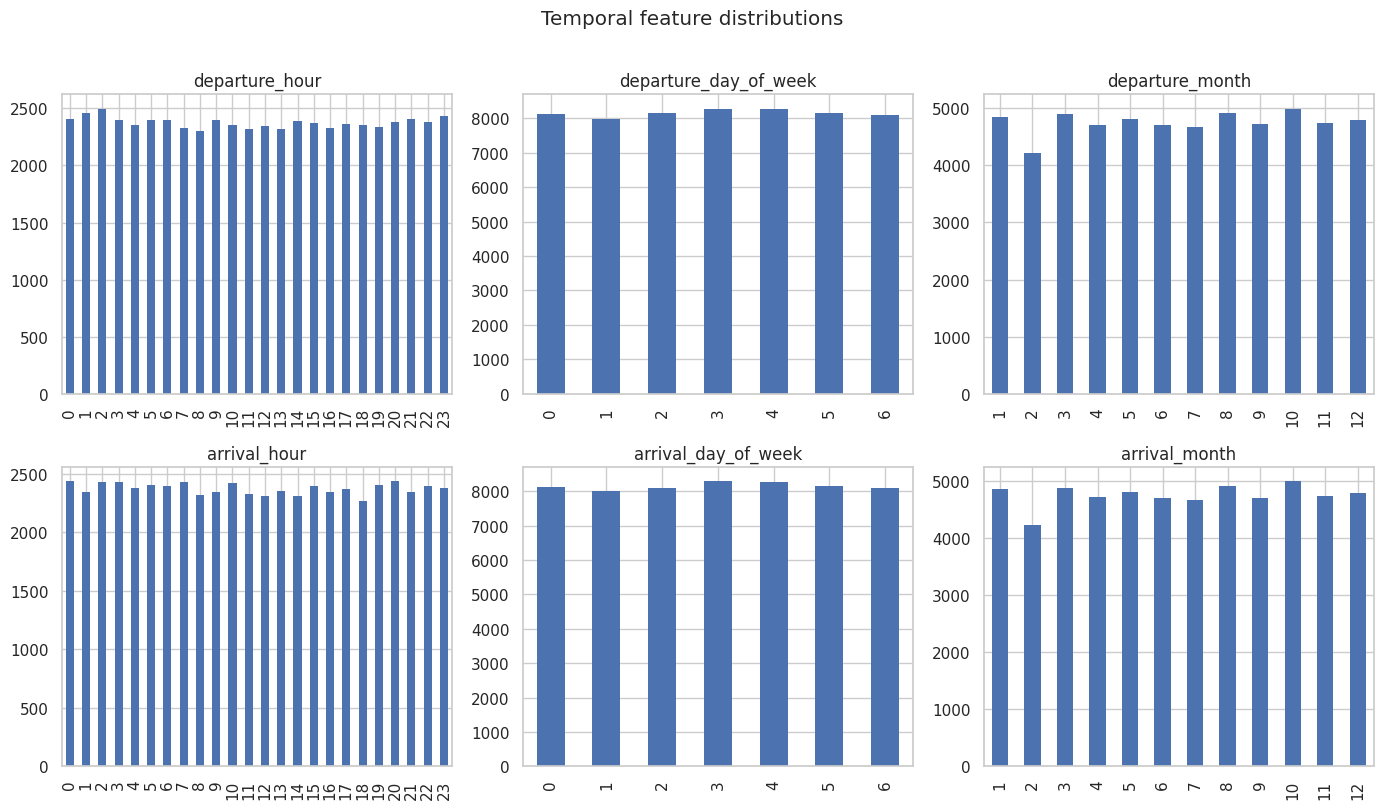

In [13]:
# Visual: distributions of new temporal features
if new_temporal:
    n = len(new_temporal)
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(14, 8))
    axes = axes.flatten()
    for i, col in enumerate(new_temporal):
        df6[col].value_counts().sort_index().plot(kind='bar', ax=axes[i], edgecolor='none')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Temporal feature distributions', y=1.01)
    plt.tight_layout()
    plt.show()

---
## 8. Ordinal-Encode Stopovers
`encode_stopovers()` maps the `stopovers` string values to integers preserving order:  
`Direct → 0`, `1 Stop → 1`, `2 Stops → 2`  

Order matters here — more stops generally mean longer travel — so ordinal encoding is correct, not one-hot.

In [14]:
print('stopovers value counts before encoding:')
print(df6['stopovers'].value_counts().to_string())
print()
print('Ordinal map:', STOPOVER_ORDINAL)

stopovers value counts before encoding:
stopovers
Direct     36642
1 Stop     17400
2 Stops     2958

Ordinal map: {'Direct': 0, '1 Stop': 1, '2 Stops': 2}


In [15]:
df7 = encode_stopovers(df6, 'stopovers', STOPOVER_ORDINAL)

print('stopovers after encoding:')
print(df7['stopovers'].value_counts().sort_index().to_string())
print('dtype:', df7['stopovers'].dtype)

2026-05-14 06:40:37 [INFO] features.cleaning: Ordinal-encoding 'stopovers' → {'Direct': 0, '1 Stop': 1, '2 Stops': 2}


Ordinal-encoding 'stopovers' → {'Direct': 0, '1 Stop': 1, '2 Stops': 2}


stopovers after encoding:
stopovers
0    36642
1    17400
2     2958
dtype: int8


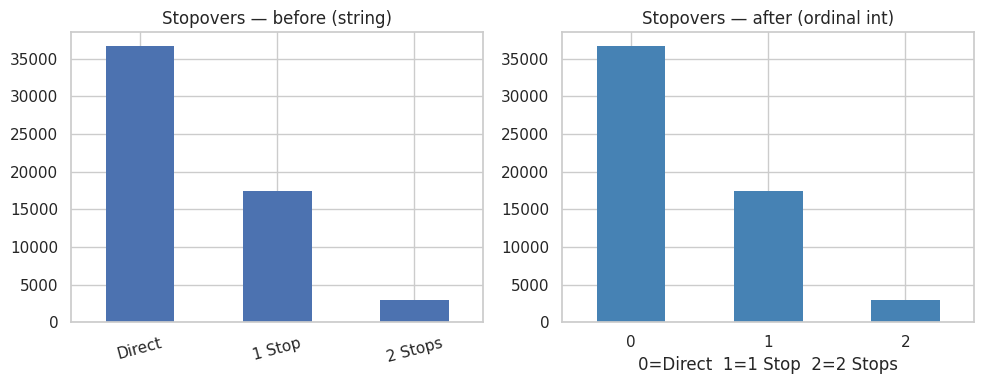

In [16]:
# Visual: stopovers distribution before vs after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df6['stopovers'].value_counts().plot(kind='bar', ax=axes[0], edgecolor='none')
axes[0].set_title('Stopovers — before (string)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

df7['stopovers'].value_counts().sort_index().plot(kind='bar', ax=axes[1], edgecolor='none', color='steelblue')
axes[1].set_title('Stopovers — after (ordinal int)')
axes[1].set_xlabel('0=Direct  1=1 Stop  2=2 Stops')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

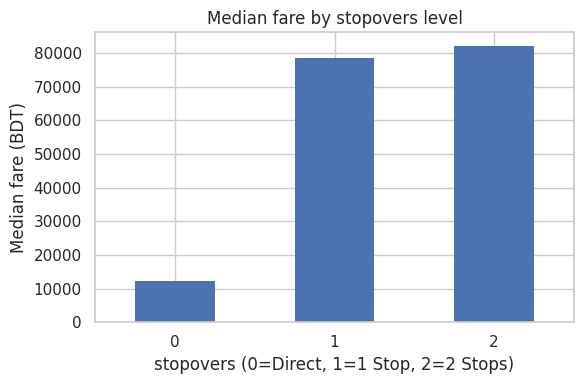

In [17]:
# Visual: median fare by stopovers level
fig, ax = plt.subplots(figsize=(6, 4))
df7.groupby('stopovers')['fare'].median().plot(kind='bar', ax=ax, edgecolor='none')
ax.set_title('Median fare by stopovers level')
ax.set_xlabel('stopovers (0=Direct, 1=1 Stop, 2=2 Stops)')
ax.set_ylabel('Median fare (BDT)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
## 9. Full Pipeline — compose all steps
`build_pipeline(cfg)` composes all 8 transforms into a single function via `functools.reduce`.  
Running it on the raw data produces the same result as chaining steps manually above.

In [18]:
# Run full pipeline on a fresh copy of raw
df_clean, report = clean(raw.copy(), cfg)

print(f'Raw shape    : {raw.shape}')
print(f'Clean shape  : {df_clean.shape}')
print()
log_report(report)

2026-05-14 06:40:38 [INFO] features.cleaning: Renaming 17 column(s) to snake_case


Renaming 17 column(s) to snake_case


2026-05-14 06:40:38 [INFO] features.cleaning: Dropping leakage columns: ['base_fare', 'tax_surcharge']


Dropping leakage columns: ['base_fare', 'tax_surcharge']


2026-05-14 06:40:38 [INFO] features.cleaning: No missing values — imputation skipped


...

  Cols removed       : -2


2026-05-14 06:40:38 [INFO] features.cleaning:   Temporal features  : ['departure_hour', 'departure_day_of_week', 'departure_month', 'arrival_hour', 'arrival_day_of_week', 'arrival_month']


  Temporal features  : ['departure_hour', 'departure_day_of_week', 'departure_month', 'arrival_hour', 'arrival_day_of_week', 'arrival_month']


2026-05-14 06:40:38 [INFO] features.cleaning:   Ordinal encoded    : ['stopovers']


  Ordinal encoded    : ['stopovers']


In [19]:
# Final column list with dtypes
pd.DataFrame({'dtype': df_clean.dtypes, 'non_null': df_clean.notna().sum()})

,dtype,non_null
airline,object,57000
source,object,57000
source_name,object,57000
destination,object,57000
destination_name,object,57000
duration,float64,57000
stopovers,int8,57000
aircraft_type,object,57000
travel_class,object,57000
booking_source,object,57000


In [20]:
df_clean.head()

,airline,source,source_name,destination,destination_name,duration,stopovers,aircraft_type,travel_class,booking_source,fare,seasonality,days_left,departure_hour,departure_day_of_week,departure_month,arrival_hour,arrival_day_of_week,arrival_month
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,1.219526,0,Airbus A320,Economy,Online Website,26300.908775,Regular,10,6,0,11,7,0,11
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",0.608638,0,Airbus A320,First Class,Travel Agency,11805.395471,Regular,14,0,6,3,0,6,3
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2.689651,1,Boeing 787,Economy,Travel Agency,51864.874251,Winter Holidays,83,12,5,12,14,5,12
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",0.686054,0,Airbus A320,Economy,Direct Booking,4635.607340,Regular,56,3,4,5,4,4,5
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,14.055609,1,Airbus A350,Business,Direct Booking,74130.377068,Regular,90,9,4,4,23,4,4


---
## 10. Save Processed Dataset
`save_processed()` writes the cleaned DataFrame to `data/processed/` as a Parquet file.  
Parquet preserves dtypes (including `int8` for ordinal/temporal columns) and loads ~5× faster than CSV.

In [21]:
processed_path = ROOT / cfg['data']['processed_path']
save_processed(df_clean, processed_path)
print(f'Saved → {processed_path}')

2026-05-14 06:40:38 [INFO] features.cleaning: Saved → /home/mbarndouka/Documents/amalitechmllab/data/processed/Flight_Price_Dataset_of_Bangladesh.parquet  (57000 rows × 19 cols)


Saved → /home/mbarndouka/Documents/amalitechmllab/data/processed/Flight_Price_Dataset_of_Bangladesh.parquet  (57000 rows × 19 cols)


Saved → /home/mbarndouka/Documents/amalitechmllab/data/processed/Flight_Price_Dataset_of_Bangladesh.parquet


In [22]:
# Round-trip check: reload from parquet and verify shape + dtypes match
reloaded = pd.read_parquet(processed_path)
assert reloaded.shape == df_clean.shape, 'Shape mismatch after reload'
print('Round-trip OK  shape:', reloaded.shape)
reloaded.dtypes

Round-trip OK  shape: (57000, 19)


airline                   object
source                    object
source_name               object
destination               object
destination_name          object
duration                 float64
stopovers                   int8
aircraft_type             object
travel_class              object
booking_source            object
fare                     float64
seasonality               object
days_left                  int64
departure_hour              int8
departure_day_of_week       int8
departure_month             int8
arrival_hour                int8
arrival_day_of_week         int8
arrival_month               int8
dtype: object

---
## Summary

| Step | Action | Result |
|------|--------|--------|
| 1 | Drop unnamed columns | No change (none present) |
| 2 | Rename to snake_case | 17 columns renamed |
| 3 | Drop leakage columns | `base_fare`, `tax_surcharge` removed |
| 4 | Drop high-missingness rows | No rows dropped |
| 5 | Impute missing values | No imputation needed |
| 6 | Parse datetime columns | 2 columns → `datetime64` |
| 7 | Extract temporal features | 6 new columns added, 2 dropped |
| 8 | Ordinal-encode stopovers | `Direct/1 Stop/2 Stops` → `0/1/2` |

**Before:** 57,000 × 17  →  **After:** 57,000 × 19  
Net +2 columns: datetime collapsed to 6 features (−2 +6), leakage dropped (−2), total 17−2−2+6 = 19.

**Next:** Step 3 — Feature Engineering (one-hot / target encoding of categorical columns, train/val/test split)